#Tyre Thermal PINN v2

#What changed from the previous iterations and why

**Problem diagnosed from my previous plots:**
- Predictions oscillating ±20°C per timestep. After fixing various issues I deduced the model had no memory and was trying to predict absolute temperature from instantaneous inputs
- Validation losses were diverging after epoch ~150. This was my indicator for overfitting.
- Physics loss kept spiking. The learning rate was too aggressive, losses competing.

**Root cause:** T(t) has a correlation of roughly 0.9999999 with T(t-1), or in words the previous temperature logged on the system. The model predicting absolute temperature from a single timestep of inputs is fighting against this. The solution in this version of my model was to make it autoregressive. This means it would now predict dT (the small change per step) and feed T(t-1) as an explicit input. This way:
1. The model only needs to learn the small residual
2. The physics constraint on dT is natural and well-scaled
3. Overfitting is reduced because dT is a harder target to memorise

**Changes:**
- Target is now dT per timestep, not absolute temperature
- T_prev (previous timestep temperatures) added as input features
- At inference time, predictions are integrated: `T(t) = T(t-1) + dT_pred(t)`
- Physics loss now directly on dT_pred vs the Newton cooling equation
- LR scheduler (ReduceLROnPlateau) added to try and eliminate validation loss spikes. In the initial stages of the training, a fast learning rate is used to quickly learn the trend. As the model gets more accurate, the learning rate will halve, preventing the model overshooting the loss minimum
- lambda_physics reduced further since dT is now in °C (small numbers)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from google.colab import drive

drive.mount('/content/drive')
df_raw = pd.read_csv('/content/drive/MyDrive/tyre_data.csv')
print(df_raw.shape)
print(df_raw.head())

Mounted at /content/drive
(172030, 34)
      timestamp  run_block  tyre_pressure_set  camber_set  track_temp_set  \
0  1.776520e+09          1               20.0        -2.5            25.0   
1  1.776520e+09          1               20.0        -2.5            25.0   
2  1.776520e+09          1               20.0        -2.5            25.0   
3  1.776520e+09          1               20.0        -2.5            25.0   
4  1.776520e+09          1               20.0        -2.5            25.0   

   lap_number  speed_kmh  throttle  brake  gear  ...  pressure_RL  \
0           0       1.56       0.0    0.0     1  ...        15.84   
1           0       0.99       0.0    1.0     1  ...        15.84   
2           0       0.32       0.0    1.0     1  ...        15.84   
3           0       0.71       0.0    1.0     1  ...        15.84   
4           0       0.67       0.0    1.0     1  ...        15.84   

   pressure_RR  camber_FL  camber_FR  camber_RL  camber_RR  temp_FL  temp_FR  \
0  

#Preprocessing

In [2]:
df = df_raw.copy()

#removing the slip outliers at per-column 99.9th percentile
slip_cols = ['slip_FL', 'slip_FR', 'slip_RL', 'slip_RR']
for col in slip_cols:
    clip_val = df[col].quantile(0.999)
    n_clipped = (df[col] > clip_val).sum()
    print(f'{col}: clipping {n_clipped} rows above {clip_val:.3f}')
    df[col] = df[col].clip(upper=clip_val)

#sort by block then by original row order to ensure time ordering
df = df.sort_values(['run_block', 'timestamp']).reset_index(drop=True)

drop_cols = ['timestamp', 'run_block', 'tyre_pressure_set', 'camber_set', 'lap_number', 'gear']
df_model = df.drop(columns=drop_cols)
print(f'\nShape: {df_model.shape}')

slip_FL: clipping 173 rows above 1.526
slip_FR: clipping 173 rows above 1.547
slip_RL: clipping 173 rows above 4.747
slip_RR: clipping 173 rows above 4.718

Shape: (172030, 28)


#Build autoregressive dataset

For each timestep t, construct:
- **Inputs X(t):** all features at t, PLUS `T_prev` = temperatures at t-1
- **Target y(t):** `dT = T(t) - T(t-1)`. the temperature change this step

The first row of each run block is dropped (no valid t-1 exists across block boundaries).

In [3]:
temp_cols = ['temp_FL', 'temp_FR', 'temp_RL', 'temp_RR']
feature_cols = [col for col in df_model.columns if col not in temp_cols]

rows_X, rows_y, rows_block = [], [], []

for block in sorted(df['run_block'].unique()):
    mask = df['run_block'] == block
    block_features = df_model.loc[mask, feature_cols].values
    block_temps = df_model.loc[mask, temp_cols].values

    #dT target: temperature change at each step (drop first row, no t-1)
    dT = block_temps[1:] - block_temps[:-1]                     # (N-1, 4)

    #features at t (current), plus T at t-1 appended
    X_curr = block_features[1:]
    T_prev = block_temps[:-1]
    X_joined = np.concatenate([X_curr, T_prev], axis=1)

    rows_X.append(X_joined)
    rows_y.append(dT)
    rows_block.append(np.full(len(dT), block))

X_all = np.concatenate(rows_X, axis=0)
y_all = np.concatenate(rows_y, axis=0)
block_all = np.concatenate(rows_block, axis=0)

#column names for the expanded feature set
t_prev_names = ['T_prev_FL', 'T_prev_FR', 'T_prev_RL', 'T_prev_RR']
all_input_cols = feature_cols + t_prev_names

print(f'\ndT stats (°C per timestep):')
print(pd.DataFrame(y_all, columns=temp_cols).describe())

X shape: (172022, 28) (28 features)
y shape: (172022, 4) (dT per wheel)

dT stats (°C per timestep):
             temp_FL        temp_FR        temp_RL        temp_RR
count  172022.000000  172022.000000  172022.000000  172022.000000
mean        0.001966       0.002118       0.002191       0.002299
std         0.005723       0.006113       0.006630       0.006752
min        -0.270000      -0.260000      -0.270000      -0.270000
25%         0.000000       0.000000       0.000000       0.000000
50%         0.000000       0.000000       0.000000       0.000000
75%         0.000000       0.000000       0.010000       0.010000
max         0.040000       0.030000       0.130000       0.110000


In [4]:
#block-based split: train on blocks 1-6, test on 7-8
train_mask = np.isin(block_all, [1, 2, 3, 4, 5, 6])
test_mask = np.isin(block_all, [7, 8])

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

#scale inputs
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set: {X_test_scaled.shape}')
print(f'\ny_train (dT) stats, should be small numbers close to 0:')
print(pd.DataFrame(y_train, columns=temp_cols).describe())

Training set: (129438, 28)
Test set: (42584, 28)

y_train (dT) stats, should be small numbers close to 0:
             temp_FL        temp_FR        temp_RL        temp_RR
count  129438.000000  129438.000000  129438.000000  129438.000000
mean        0.001946       0.002088       0.002172       0.002270
std         0.005701       0.006055       0.006621       0.006702
min        -0.270000      -0.260000      -0.270000      -0.270000
25%         0.000000       0.000000       0.000000       0.000000
50%         0.000000       0.000000       0.000000       0.000000
75%         0.000000       0.000000       0.010000       0.010000
max         0.040000       0.030000       0.130000       0.110000


In [5]:
#feature indices in the (unscaled) input for physics loss
print('Feature order:')
for i, col in enumerate(all_input_cols):
    print(f' {i}: {col}')

slip_idx = [all_input_cols.index(c) for c in ['slip_FL', 'slip_FR', 'slip_RL', 'slip_RR']]
load_idx = [all_input_cols.index(c) for c in ['load_FL', 'load_FR', 'load_RL', 'load_RR']]
t_prev_idx = [all_input_cols.index(c) for c in t_prev_names]
track_temp_idx = all_input_cols.index('track_temp_set')

print('\nSlip idx:', slip_idx)
print('Load idx:', load_idx)
print('T_prev idx:', t_prev_idx)
print('Track temp idx:', track_temp_idx)

Feature order:
 0: track_temp_set
 1: speed_kmh
 2: throttle
 3: brake
 4: rpms
 5: steer_angle
 6: long_accel_g
 7: lat_accel_g
 8: slip_FL
 9: slip_FR
 10: slip_RL
 11: slip_RR
 12: load_FL
 13: load_FR
 14: load_RL
 15: load_RR
 16: pressure_FL
 17: pressure_FR
 18: pressure_RL
 19: pressure_RR
 20: camber_FL
 21: camber_FR
 22: camber_RL
 23: camber_RR
 24: T_prev_FL
 25: T_prev_FR
 26: T_prev_RL
 27: T_prev_RR

Slip idx: [8, 9, 10, 11]
Load idx: [12, 13, 14, 15]
T_prev idx: [24, 25, 26, 27]
Track temp idx: 0


#Model predicts dT


In [6]:
class TyrePINN(nn.Module):
    def __init__(self, input_size, output_size=4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.network(x)

INPUT_SIZE = len(all_input_cols)  # 28: original 24 + 4 T_prev
print(f'Input size: {INPUT_SIZE}')
model = TyrePINN(input_size=INPUT_SIZE)
print(f'Total parameters: {sum(p.numel() for p in model.parameters())}')

Input size: 28
Total parameters: 35204


#Training

The physics constraint is now directly on the predicted dT:
```
dT_pred  =  alpha*(slip*load)  -  beta*(T_prev - T_ambient)
```
`dT_pred` is the model output. `T_prev` comes directly from the input features, already in °C.

The LR scheduler halves the learning rate when validation loss stops improving, which eliminates the periodic spikes seen in v1.

In [7]:
learning_rate = 1e-3
epochs = 500
lambda_physics = 0.05
batch_size = 1024

#physics coefficients (°C, N, slip ratio per 20ms timestep)
alpha = 3e-6  #frictional heat generation per (N·slip) per step
beta  = 5e-4  #newton cooling coefficient per step

#scaler arrays for unscaling slip, load, T_prev inside the loop
slip_mean_np = scaler_X.mean_[slip_idx]
slip_std_np = scaler_X.scale_[slip_idx]
load_mean_np = scaler_X.mean_[load_idx]
load_std_np = scaler_X.scale_[load_idx]
tprev_mean_np = scaler_X.mean_[t_prev_idx]
tprev_std_np = scaler_X.scale_[t_prev_idx]
ttrack_mean = float(scaler_X.mean_[track_temp_idx])
ttrack_std = float(scaler_X.scale_[track_temp_idx])

slip_mean_t = torch.tensor(slip_mean_np, dtype=torch.float32)
slip_std_t = torch.tensor(slip_std_np, dtype=torch.float32)
load_mean_t = torch.tensor(load_mean_np, dtype=torch.float32)
load_std_t = torch.tensor(load_std_np, dtype=torch.float32)
tprev_mean_t = torch.tensor(tprev_mean_np, dtype=torch.float32)
tprev_std_t = torch.tensor(tprev_std_np, dtype=torch.float32)

#tensors and DataLoader
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = TyrePINN(input_size=INPUT_SIZE)
optimiser = optim.Adam(model.parameters(), lr=learning_rate)

#halve LR when val loss hasn't improved for 20 epochs, should remove the spiking
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=20)
mse_loss = nn.MSELoss()

train_losses, val_losses, physics_losses, lr_history = [], [], [], []

for epoch in range(epochs):
    model.train()
    epoch_data_loss = epoch_physics_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in train_loader:
        optimiser.zero_grad()

        dT_pred = model(X_batch) # predicted dT in °C
        loss_data = mse_loss(dT_pred, y_batch)

        # physics loss
        # unscale features back to physical units
        slip_real = X_batch[:, slip_idx] * slip_std_t + slip_mean_t # slip ratio
        load_real = X_batch[:, load_idx] * load_std_t + load_mean_t # Newtons
        T_prev_val = X_batch[:, t_prev_idx] * tprev_std_t + tprev_mean_t # °C
        T_ambient = (X_batch[:, track_temp_idx:track_temp_idx+1] * ttrack_std + ttrack_mean)

        #newton cooling: dT = alpha*(slip*load) - beta*(T_prev - T_ambient)
        dT_physics = (alpha * slip_real * load_real - beta * (T_prev_val - T_ambient))

        loss_physics = mse_loss(dT_pred, dT_physics)
        loss = loss_data + lambda_physics * loss_physics
        loss.backward()
        optimiser.step()

        epoch_data_loss += loss_data.item()
        epoch_physics_loss += loss_physics.item()
        num_batches += 1

    avg_data_loss = epoch_data_loss / num_batches
    avg_physics_loss = epoch_physics_loss / num_batches

    model.eval()
    with torch.no_grad():
        dT_val_pred = model(X_test_t)
        val_loss = mse_loss(dT_val_pred, y_test_t)

    scheduler.step(val_loss)

    train_losses.append(avg_data_loss)
    val_losses.append(val_loss.item())
    physics_losses.append(avg_physics_loss)
    lr_history.append(optimiser.param_groups[0]['lr'])

    if epoch % 100 == 0:
        print(f'Epoch {epoch:4d} | '
              f'Data: {avg_data_loss:.6f} | '
              f'Physics: {avg_physics_loss:.6f} | '
              f'Val: {val_loss.item():.6f} | '
              f'LR: {optimiser.param_groups[0]["lr"]:.2e}')

Epoch    0 | Data: 0.000313 | Physics: 0.000595 | Val: 0.000026 | LR: 1.00e-03
Epoch  100 | Data: 0.000018 | Physics: 0.000310 | Val: 0.000018 | LR: 5.00e-04
Epoch  200 | Data: 0.000018 | Physics: 0.000311 | Val: 0.000018 | LR: 6.25e-05
Epoch  300 | Data: 0.000018 | Physics: 0.000311 | Val: 0.000018 | LR: 1.95e-06
Epoch  400 | Data: 0.000018 | Physics: 0.000311 | Val: 0.000018 | LR: 6.10e-08


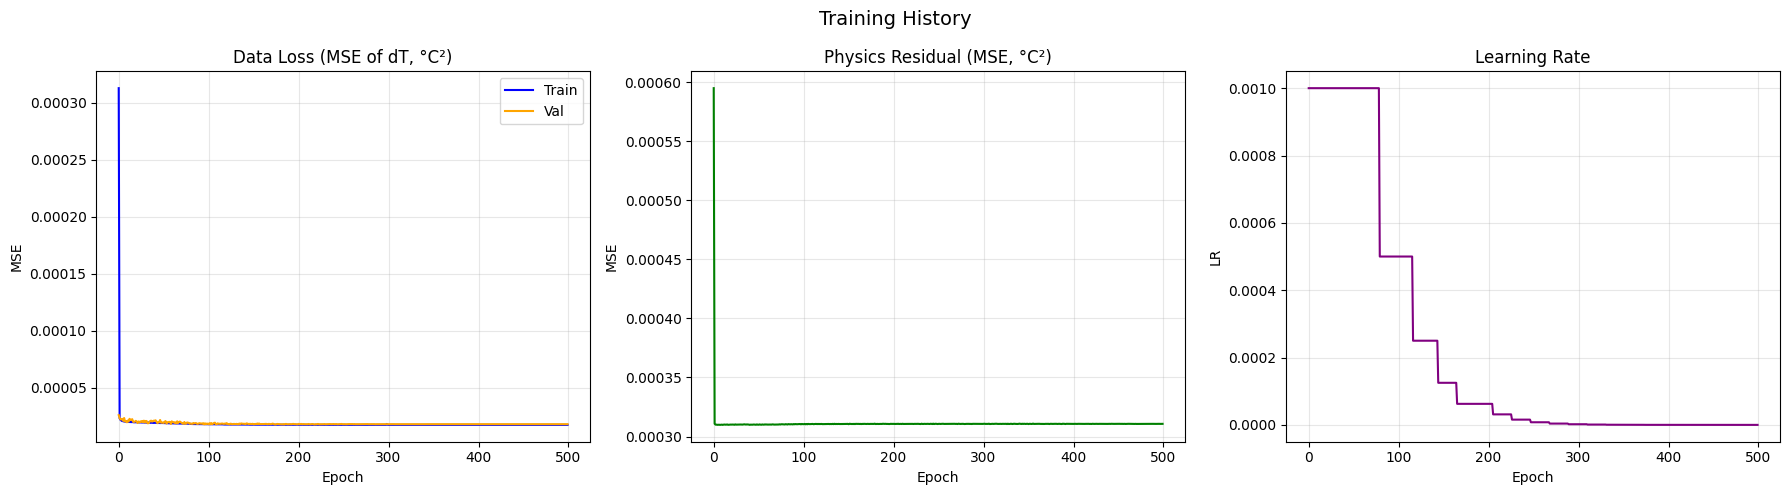

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14)

axes[0].plot(train_losses, label='Train', color='blue')
axes[0].plot(val_losses, label='Val', color='orange')
axes[0].set_title('Data Loss (MSE of dT, °C²)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(physics_losses, color='green')
axes[1].set_title('Physics Residual (MSE, °C²)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE'); axes[1].grid(True, alpha=0.3)

axes[2].plot(lr_history, color='purple')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Evaluation

At inference time integrate the predicted dT step-by-step:
```
T(t) = T(t-1) + dT_pred(t)
```
In practise the model is given a starting temperature and a sequence of inputs, and then roll forward through time. The integration is done per block to avoid carrying errors across block boundaries.

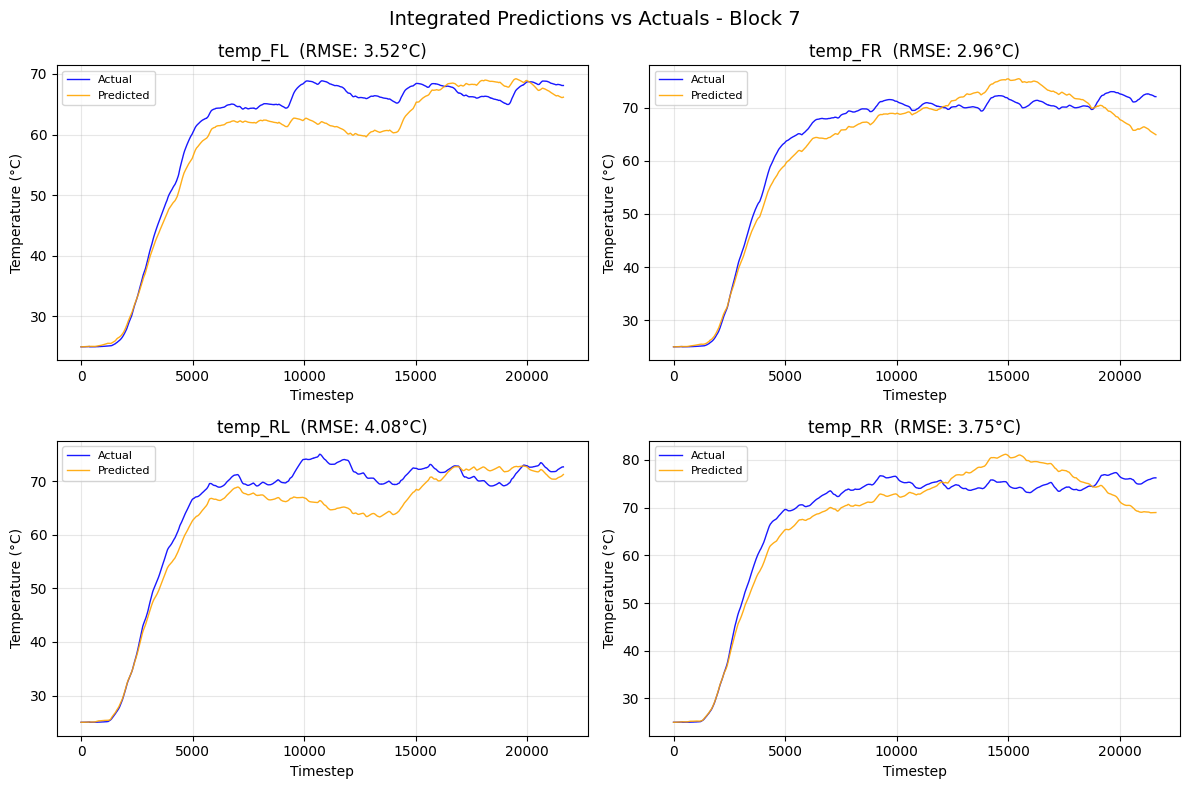


Block 7 per-corner RMSE:
  temp_FL: 3.52°C
  temp_FR: 2.96°C
  temp_RL: 4.08°C
  temp_RR: 3.75°C


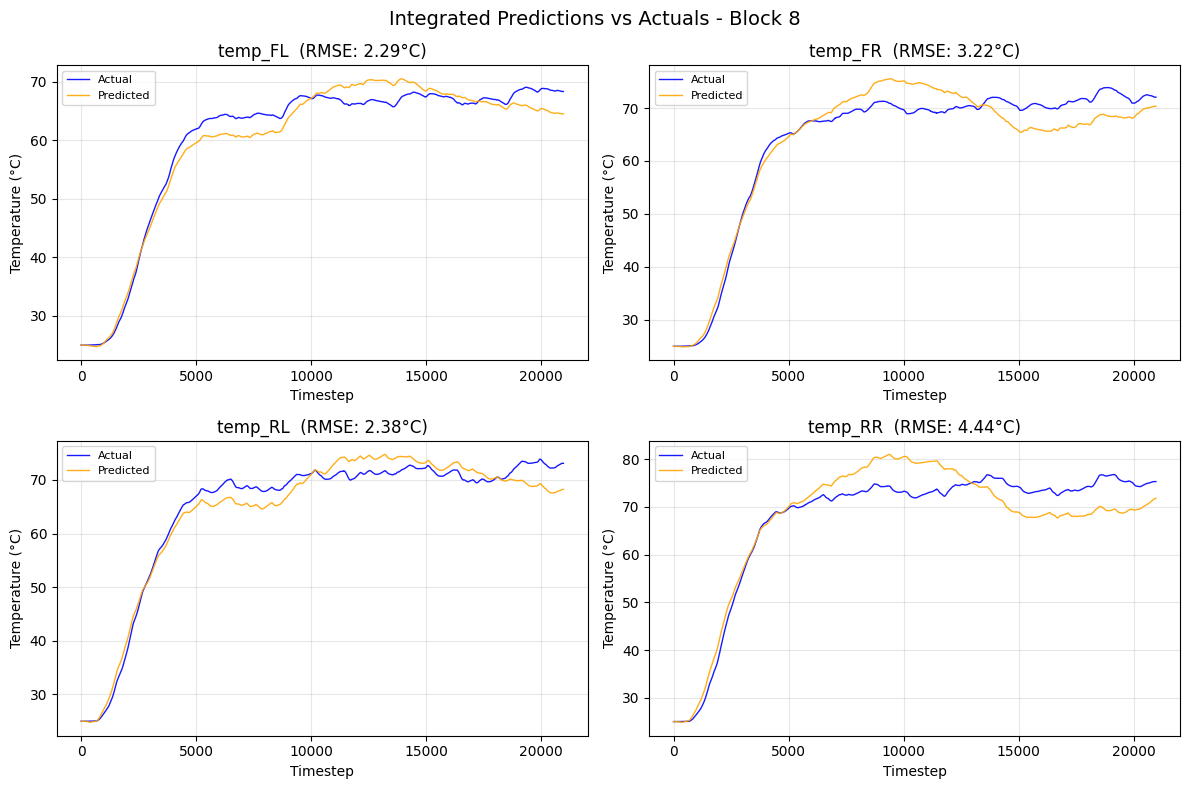


Block 8 per-corner RMSE:
  temp_FL: 2.29°C
  temp_FR: 3.22°C
  temp_RL: 2.38°C
  temp_RR: 4.44°C


In [13]:
model.eval()

#reconstruct absolute temperature by integrating dT predictions per block
all_actual, all_predicted = [], []

for block in [7, 8]:
    mask  = df['run_block'] == block
    block_features = df_model.loc[mask, feature_cols].values
    block_temps = df_model.loc[mask, temp_cols].values #ground truth absolute T

    T_prev = block_temps[0:1].copy()  #seed with actual starting temperature
    T_integrated = [T_prev[0]]

    for t in range(1, len(block_temps)):
        X_row = np.concatenate([block_features[t], T_prev[0]])[np.newaxis, :]  # (1, 28)
        X_scaled = scaler_X.transform(X_row)
        X_t = torch.tensor(X_scaled, dtype=torch.float32)

        with torch.no_grad():
            dT = model(X_t).numpy()[0] # predicted dT in °C

        T_new = T_prev[0] + dT
        T_integrated.append(T_new)
        T_prev = T_new[np.newaxis, :]

    all_actual.append(block_temps)
    all_predicted.append(np.array(T_integrated))

actual_all = np.concatenate(all_actual, axis=0)
predicted_all = np.concatenate(all_predicted, axis=0)

for block_idx, block in enumerate([7, 8]): #plotting
    actual    = all_actual[block_idx]
    predicted = all_predicted[block_idx]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'Integrated Predictions vs Actuals - Block {block}', fontsize=14)

    for i, corner in enumerate(temp_cols):
        ax = axes[i // 2, i % 2]
        ax.plot(actual[:, i],    alpha=0.9, label='Actual',    color='blue',   linewidth=1)
        ax.plot(predicted[:, i], alpha=0.9, label='Predicted', color='orange', linewidth=1)
        rmse = np.sqrt(np.mean((predicted[:, i] - actual[:, i])**2))
        ax.set_title(f'{corner}  (RMSE: {rmse:.2f}°C)')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Temperature (°C)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'\nBlock {block} per-corner RMSE:')
    for i, corner in enumerate(temp_cols):
        rmse = np.sqrt(np.mean((predicted[:, i] - actual[:, i])**2))
        print(f'  {corner}: {rmse:.2f}°C')

# Step wise accuracy (non-integrated)

This checks the model's dT prediction quality directly by using the actual T(t-1) at each step, not the accumulated predicted T. This isolates model accuracy from integration drift.

In [10]:
model.eval()
with torch.no_grad():
    dT_pred_test = model(X_test_t).numpy()

print('Step-wise dT prediction RMSE (°C per timestep):')
for i, corner in enumerate(temp_cols):
    rmse = np.sqrt(np.mean((dT_pred_test[:, i] - y_test[:, i])**2))
    print(f' {corner}: {rmse:.5f}°C/step')

print(f'\n(Actual dT std is ~{y_test.std():.5f}°C/step for reference)')

Step-wise dT prediction RMSE (°C per timestep):
 temp_FL: 0.00399°C/step
 temp_FR: 0.00425°C/step
 temp_RL: 0.00436°C/step
 temp_RR: 0.00446°C/step

(Actual dT std is ~0.00642°C/step for reference)
